In [3]:
import re
import torch
import numpy as np
import inflect
import matplotlib.pyplot as plt
from phonemizer import phonemize
from phonemizer.backend import EspeakBackend
engine=inflect.engine()
print("Imports Ok")


Imports Ok


In [4]:
PHONEMES=[
    "<pad>",
    "<sos>",
    "<eos>",
    " ",
    "AA",
    "AE",
    "AH",
    "AO",
    "AW",
    "AY",
    "EH",
    "ER",
    "EY",
    "IH",
    "IY",
    "OW",
    "OY",
    "UH",
    "UW",
    "B",
    "CH",
    "D",
    "DH",
    "F",
    "G",
    "HH",
    "JH",
    "K",
    "L",
    "M",
    "N",
    "NG",
    "P",
    "R",
    "S",
    "SH",
    "T",
    "TH",
    "V",
    "W",
    "X",
    "Y",
    "Z",
    "ZH",
]
phoneme_to_id={p:i for i,p in enumerate(PHONEMES)}
id_to_phoneme={i:p for i,p in enumerate(PHONEMES)}
VOCAB_SIZE=len(PHONEMES)
PAD_ID = phoneme_to_id["<pad>"]   # = 0
SOS_ID = phoneme_to_id["<sos>"]   # = 1
EOS_ID = phoneme_to_id["<eos>"]   # = 2
SPC_ID = phoneme_to_id[" "]       # = 3

print(f"Vocabulary size: {VOCAB_SIZE} tokens")
print(f"\nSpecial token IDs:")
print(f"  <pad> = {PAD_ID}")
print(f"  <sos> = {SOS_ID}")
print(f"  <eos> = {EOS_ID}")
print(f"  ' '   = {SPC_ID}  (word boundary)")
print(f"\nSample phoneme IDs:")
for ph in ["AA", "B", "IY", "S", "T", "ZH"]:
    print(f"  {ph:4s} → {phoneme_to_id[ph]}")

Vocabulary size: 44 tokens

Special token IDs:
  <pad> = 0
  <sos> = 1
  <eos> = 2
  ' '   = 3  (word boundary)

Sample phoneme IDs:
  AA   → 4
  B    → 19
  IY   → 14
  S    → 34
  T    → 36
  ZH   → 43


In [5]:
def normalize_text(text:str)-> str:
    text=text.lower()
    abbreviations={
        r"\bdr\.":"doctor",
        r"\bmr\.":"mister",
        r"\bmrs\.":"misses",
        r"\bms\.":"miss",
        r"\bst\.":"saint",
        r"\bvs\.":"versus",
        r"\betc\.":"et cetera",
        r"\be\.g\.":"for example",
        r"\bi\.e\.":"that is",
        r"\bft\.":"feet",
        r"\boz\.":"ounces",
        r"\blbs?\.":"pounds",
        r"\bjr\.":"junior",
        r"\bsr\.":"senior",
        r"\bapt\.":"apartment",
        r"\bblvd\.":"boulevard",
        r"\bave\.":"avenue",
        r"\brd\.":"road",
    }
    for pattern, replacement in abbreviations.items():
        text=re.sub(pattern, replacement,text)
    def expand_currency(match):
        amount=match.group(1)
        try:
            num=int(float(amount))
            word=engine.number_to_words(num)
        except:
            word=amount
        return f"{word} dollars"
    
    text = re.sub(r'\$([0-9]+(?:\.[0-9]+)?)', expand_currency, text)
    text = re.sub(r'£([0-9]+(?:\.[0-9]+)?)',
                  lambda m: f"{engine.number_to_words(int(float(m.group(1))))} pounds", text)
    text = re.sub(r'€([0-9]+(?:\.[0-9]+)?)',
                  lambda m: f"{engine.number_to_words(int(float(m.group(1))))} euros", text)
    text = re.sub(
        r'([0-9]+(?:\.[0-9]+)?)\s*%',
        lambda m: f"{engine.number_to_words(int(float(m.group(1))))} percent",
        text
    )
    def expand_number(match):
        num_str = match.group(0).replace(",", "")
        try:
            num = int(num_str)
            # Years: 1900-2099 → spoken as pairs ("nineteen eighty four")
            if 1000 <= num <= 2099 and len(num_str) == 4:
                # Split year into two halves: 1984 → "nineteen" + "eighty four"
                first  = num // 100   # 19
                second = num % 100    # 84
                if second == 0:
                    return engine.number_to_words(first) + " hundred"
                else:
                    return (engine.number_to_words(first) + " " +
                            engine.number_to_words(second))
            return engine.number_to_words(num)
        except:
            return match.group(0)  # leave unchanged if conversion fails

    text = re.sub(r'\b[0-9]{1,3}(?:,[0-9]{3})*\b|[0-9]+', expand_number, text)

    # ── Step 6: Expand common symbols ────────────────────────────────────
    text = text.replace("&",  " and ")
    text = text.replace("+",  " plus ")
    text = text.replace("=",  " equals ")
    text = text.replace("@",  " at ")
    text = text.replace("#",  " number ")
    text = text.replace("/",  " slash ")
    text = text.replace("\\", " backslash ")
    text = text.replace("*",  " times ")

    # ── Step 7: Handle punctuation ────────────────────────────────────────
    # Keep: apostrophes (it's, don't), hyphens (well-known), periods/commas/
    #       question marks/exclamation marks (affect prosody).
    # Remove: everything else (brackets, quotes, etc.)
    text = re.sub(r"[\"()\[\]{}<>|_~`]", "", text)

    # Normalize multiple spaces to one
    text = re.sub(r"\s+", " ", text)

    # Strip leading/trailing whitespace
    text = text.strip()
    return text




In [6]:
test_cases = [
    "Hello, my name is Aryan.",
    "Dr. Smith paid $50 in 2024.",
    "The score was 3 & 2, or about 60%.",
    "I live at 42 Baker St.",
    "It costs £30 + tax.",
    "The year 1984 was interesting.",
    "Add 1,000,000 to the budget.",
]

print("Text Normalization Results:")
print("-" * 60)
for text in test_cases:
    normalized = normalize_text(text)
    print(f"IN:  {text}")
    print(f"OUT: {normalized}")
    print()

Text Normalization Results:
------------------------------------------------------------
IN:  Hello, my name is Aryan.
OUT: hello, my name is aryan.

IN:  Dr. Smith paid $50 in 2024.
OUT: doctor smith paid fifty dollars in twenty twenty-four.

IN:  The score was 3 & 2, or about 60%.
OUT: the score was three and two, or about sixty percent.

IN:  I live at 42 Baker St.
OUT: i live at forty-two baker saint

IN:  It costs £30 + tax.
OUT: it costs thirty pounds plus tax.

IN:  The year 1984 was interesting.
OUT: the year nineteen eighty-four was interesting.

IN:  Add 1,000,000 to the budget.
OUT: add one million to the budget.



In [7]:
def text_to_phonemes(text: str) -> list[str]:
    """
    Convert normalized text to a list of ARPAbet phoneme strings.
    
    Uses espeak-ng under the hood via the phonemizer library.
    espeak-ng has a massive pronunciation dictionary plus G2P rules
    for words not in the dictionary.
    
    Returns a flat list of phoneme strings with " " between words.
    Example:
        "hello world" → ["HH", "AH", "L", "OW", " ", "W", "ER", "L", "D"]
    """

    # phonemizer.phonemize() converts text to IPA by default.
    # We configure it to use ARPAbet (called "en-us" with arpabet backend).
    # 
    # with_stress=False: ignore stress markers (AH0 vs AH1 vs AH2 → all AH)
    #   Stress adds info but also triples vocabulary size. We skip it for now.
    #   (Week 5 variance adaptor will handle prosody separately.)
    #
    # language_switch="remove-flags": if a word isn't in English dictionary,
    #   just phonemize it anyway without adding language markers.

    raw = phonemize(
        text,
        backend="espeak",
        language="en-us",
        with_stress=False,
        preserve_punctuation=False,
        punctuation_marks=";:,.!?¡¿—…«»\"\"",
        language_switch="remove-flags",
    )

    # raw is a string of IPA symbols like "həlˈoʊ wˈɜːld"
    # We need to convert IPA → ARPAbet.
    # espeak can output ARPAbet directly with the right settings.
    # Let's use a cleaner approach: use epitran or just map IPA to ARPAbet.
    
    # Actually the cleanest approach for our project:
    # Use the CMU Pronouncing Dictionary directly for known words,
    # fall back to espeak for unknown words.
    # Let's build that.

    return _ipa_string_to_arpabet(raw)


def _ipa_string_to_arpabet(ipa: str) -> list[str]:
    """
    Convert an IPA string (from espeak) to ARPAbet phoneme list.
    
    espeak outputs IPA. We map IPA symbols to ARPAbet.
    This mapping handles American English phonemes.
    """

    # IPA → ARPAbet mapping for American English
    # Left side: IPA symbol(s) from espeak
    # Right side: ARPAbet symbol we use
    IPA_TO_ARPABET = {
        # Vowels
        "ɑ":  "AA",  "ɑː": "AA",
        "æ":  "AE",
        "ʌ":  "AH",  "ə":  "AH",
        "ɔ":  "AO",  "ɔː": "AO",
        "aʊ": "AW",
        "aɪ": "AY",
        "ɛ":  "EH",  "e":  "EH",
        "ɜ":  "ER",  "ɜː": "ER",  "ɝ": "ER",
        "eɪ": "EY",
        "ɪ":  "IH",
        "iː": "IY",  "i":  "IY",
        "oʊ": "OW",
        "ɔɪ": "OY",
        "ʊ":  "UH",
        "uː": "UW",  "u":  "UW",
        # Consonants
        "b":  "B",
        "tʃ": "CH",
        "d":  "D",
        "ð":  "DH",
        "f":  "F",
        "ɡ":  "G",   "g":  "G",
        "h":  "HH",
        "dʒ": "JH",
        "k":  "K",
        "l":  "L",
        "m":  "M",
        "n":  "N",
        "ŋ":  "NG",
        "p":  "P",
        "ɹ":  "R",   "r":  "R",
        "s":  "S",
        "ʃ":  "SH",
        "t":  "T",
        "θ":  "TH",
        "v":  "V",
        "w":  "W",
        "j":  "Y",
        "z":  "Z",
        "ʒ":  "ZH",
    }

    # Strip stress markers and other diacritics espeak adds
    # ˈ = primary stress, ˌ = secondary stress, ː = long vowel marker
    ipa_clean = re.sub(r"[ˈˌː͡]", "", ipa)

    phoneme_list = []
    i = 0

    while i < len(ipa_clean):
        char = ipa_clean[i]

        # Word boundary (space) → insert space token
        if char == " ":
            if phoneme_list and phoneme_list[-1] != " ":
                phoneme_list.append(" ")
            i += 1
            continue

        # Try matching 2-character IPA sequences first (diphthongs like "aʊ")
        if i + 1 < len(ipa_clean):
            two_char = ipa_clean[i:i+2]
            if two_char in IPA_TO_ARPABET:
                phoneme_list.append(IPA_TO_ARPABET[two_char])
                i += 2
                continue

        # Try single character
        if char in IPA_TO_ARPABET:
            phoneme_list.append(IPA_TO_ARPABET[char])
            i += 1
            continue

        # Unknown character — skip (punctuation remnants, etc.)
        i += 1

    # Clean up: remove leading/trailing spaces, collapse multiple spaces
    while phoneme_list and phoneme_list[0] == " ":
        phoneme_list.pop(0)
    while phoneme_list and phoneme_list[-1] == " ":
        phoneme_list.pop()

    return phoneme_list
test_words = [
    "hello",
    "world",
    "voice",
    "neural",
    "the quick brown fox",
]

print("Phonemization Results:")
print("-" * 60)
for text in test_words:
    phonemes = text_to_phonemes(text)
    print(f"Text:     '{text}'")
    print(f"Phonemes: {phonemes}")
    print(f"Count:    {len(phonemes)} phonemes")
    print()

Phonemization Results:
------------------------------------------------------------
Text:     'hello'
Phonemes: ['HH', 'AH', 'L', 'OW']
Count:    4 phonemes

Text:     'world'
Phonemes: ['W', 'ER', 'L', 'D']
Count:    4 phonemes

Text:     'voice'
Phonemes: ['V', 'OY', 'S']
Count:    3 phonemes

Text:     'neural'
Phonemes: ['N', 'UH', 'R', 'R', 'AH', 'L']
Count:    6 phonemes

Text:     'the quick brown fox'
Phonemes: ['DH', 'AH', ' ', 'K', 'W', 'IH', 'K', ' ', 'B', 'R', 'AW', 'N', ' ', 'F', 'AA', 'K', 'S']
Count:    17 phonemes



In [8]:
def phonemes_to_ids(phonemes:list[str])-> list[int]:
    ids=[SOS_ID]
    for ph in phonemes:
        if ph in phoneme_to_id:
            ids.append(phoneme_to_id[ph])
        else:
            print(f"Warning: Unknown phoneme {ph}. Skipping...")
    ids.append(EOS_ID)
    return ids
def ids_to_phonemes(ids: list[int])-> list[str]:
    return [id_to_phoneme[i] for i in ids if i in id_to_phoneme]
sample_phonemes = ["HH", "AH", "L", "OW", " ", "W", "ER", "L", "D"]
sample_ids      = phonemes_to_ids(sample_phonemes)
recovered       = ids_to_phonemes(sample_ids)

print("Tokenization:")
print(f"  Phonemes: {sample_phonemes}")
print(f"  IDs:      {sample_ids}")
print(f"  Decoded:  {recovered}")
print()
print("ID breakdown:")
for ph, id_ in zip(recovered, sample_ids):
    print(f"  {ph:6s} → {id_:2d}")

Tokenization:
  Phonemes: ['HH', 'AH', 'L', 'OW', ' ', 'W', 'ER', 'L', 'D']
  IDs:      [1, 25, 6, 28, 15, 3, 39, 11, 28, 21, 2]
  Decoded:  ['<sos>', 'HH', 'AH', 'L', 'OW', ' ', 'W', 'ER', 'L', 'D', '<eos>']

ID breakdown:
  <sos>  →  1
  HH     → 25
  AH     →  6
  L      → 28
  OW     → 15
         →  3
  W      → 39
  ER     → 11
  L      → 28
  D      → 21
  <eos>  →  2


In [9]:
def pad_sequence(sequneces: list[list[int]],pad_id:int=PAD_ID)-> torch.tensor:
    max_len=max(len(s) for s in sequneces)
    padded=[]
    for seq in sequneces:
        n_pad=max_len-len(seq)
        padded.append(seq+[pad_id]*n_pad)
    return torch.LongTensor(padded)
def make_padding_mask(token_ids:torch.tensor)->torch.tensor:
    return token_ids!=PAD_ID
sentences = [
    "hello",
    "voice cloning",
    "my name is aryan",
]

print("Batching pipeline:")
print("-" * 60)

# Process each sentence through the full pipeline
all_ids = []
for sentence in sentences:
    normalized  = normalize_text(sentence)
    phonemes    = text_to_phonemes(normalized)
    ids         = phonemes_to_ids(phonemes)

    print(f"'{sentence}'")
    print(f"  normalized : '{normalized}'")
    print(f"  phonemes   : {phonemes}")
    print(f"  ids        : {ids}")
    print(f"  length     : {len(ids)}")
    print()

    all_ids.append(ids)

# Pad and stack
batch = pad_sequence(all_ids)
mask  = make_padding_mask(batch)

print(f"Batch tensor shape:  {batch.shape}  [batch_size × max_length]")
print(f"Padding mask shape:  {mask.shape}")
print()
print("Batch (padded):")
print(batch)
print()
print("Padding mask (True=real, False=padding):")
print(mask) 

Batching pipeline:
------------------------------------------------------------
'hello'
  normalized : 'hello'
  phonemes   : ['HH', 'AH', 'L', 'OW']
  ids        : [1, 25, 6, 28, 15, 2]
  length     : 6

'voice cloning'
  normalized : 'voice cloning'
  phonemes   : ['V', 'OY', 'S', ' ', 'K', 'L', 'OW', 'N', 'IH', 'NG']
  ids        : [1, 38, 16, 34, 3, 27, 28, 15, 30, 13, 31, 2]
  length     : 12

'my name is aryan'
  normalized : 'my name is aryan'
  phonemes   : ['M', 'AY', ' ', 'N', 'EY', 'M', ' ', 'IH', 'Z', ' ', 'AA', 'R', 'R', 'IH', 'AH', 'N']
  ids        : [1, 29, 9, 3, 30, 12, 29, 3, 13, 42, 3, 4, 33, 33, 13, 6, 30, 2]
  length     : 18

Batch tensor shape:  torch.Size([3, 18])  [batch_size × max_length]
Padding mask shape:  torch.Size([3, 18])

Batch (padded):
tensor([[ 1, 25,  6, 28, 15,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 1, 38, 16, 34,  3, 27, 28, 15, 30, 13, 31,  2,  0,  0,  0,  0,  0,  0],
        [ 1, 29,  9,  3, 30, 12, 29,  3, 13, 42,  3,  

In [10]:
def text_to_tensor(text:str)->tuple[torch.Tensor,list[str],str]:
    normalized=normalize_text(text)
    phonemes=text_to_phonemes(normalized)
    ids=phonemes_to_ids(phonemes)
    tensor=torch.LongTensor(ids).unsqueeze(0)
    return tensor, phonemes, normalized
test_sentence = "Hello, my name is Aryan and I am building a voice cloning system."

tensor, phonemes, normalized = text_to_tensor(test_sentence)

print("Full Pipeline Output:")
print("=" * 60)
print(f"Input:      '{test_sentence}'")
print(f"Normalized: '{normalized}'")
print(f"Phonemes:   {phonemes}")
print(f"Tensor shape: {tensor.shape}  [batch=1, seq_len={tensor.shape[1]}]")
print(f"Tensor values: {tensor[0].tolist()}")
print()
print("Decoded back to verify:")
decoded = ids_to_phonemes(tensor[0].tolist())
print(f"  {decoded}")

Full Pipeline Output:
Input:      'Hello, my name is Aryan and I am building a voice cloning system.'
Normalized: 'hello, my name is aryan and i am building a voice cloning system.'
Phonemes:   ['HH', 'AH', 'L', 'OW', ' ', 'M', 'AY', ' ', 'N', 'EY', 'M', ' ', 'IH', 'Z', ' ', 'AA', 'R', 'R', 'IH', 'AH', 'N', ' ', 'AE', 'N', 'D', ' ', 'AY', ' ', 'AE', 'M', ' ', 'B', 'IH', 'L', 'D', 'IH', 'NG', ' ', 'V', 'OY', 'S', ' ', 'K', 'L', 'OW', 'N', 'IH', 'NG', ' ', 'S', 'IH', 'S', 'T', 'AH', 'M']
Tensor shape: torch.Size([1, 57])  [batch=1, seq_len=57]
Tensor values: [1, 25, 6, 28, 15, 3, 29, 9, 3, 30, 12, 29, 3, 13, 42, 3, 4, 33, 33, 13, 6, 30, 3, 5, 30, 21, 3, 9, 3, 5, 29, 3, 19, 13, 28, 21, 13, 31, 3, 38, 16, 34, 3, 27, 28, 15, 30, 13, 31, 3, 34, 13, 34, 36, 6, 29, 2]

Decoded back to verify:
  ['<sos>', 'HH', 'AH', 'L', 'OW', ' ', 'M', 'AY', ' ', 'N', 'EY', 'M', ' ', 'IH', 'Z', ' ', 'AA', 'R', 'R', 'IH', 'AH', 'N', ' ', 'AE', 'N', 'D', ' ', 'AY', ' ', 'AE', 'M', ' ', 'B', 'IH', 'L', 'D', 'IH'

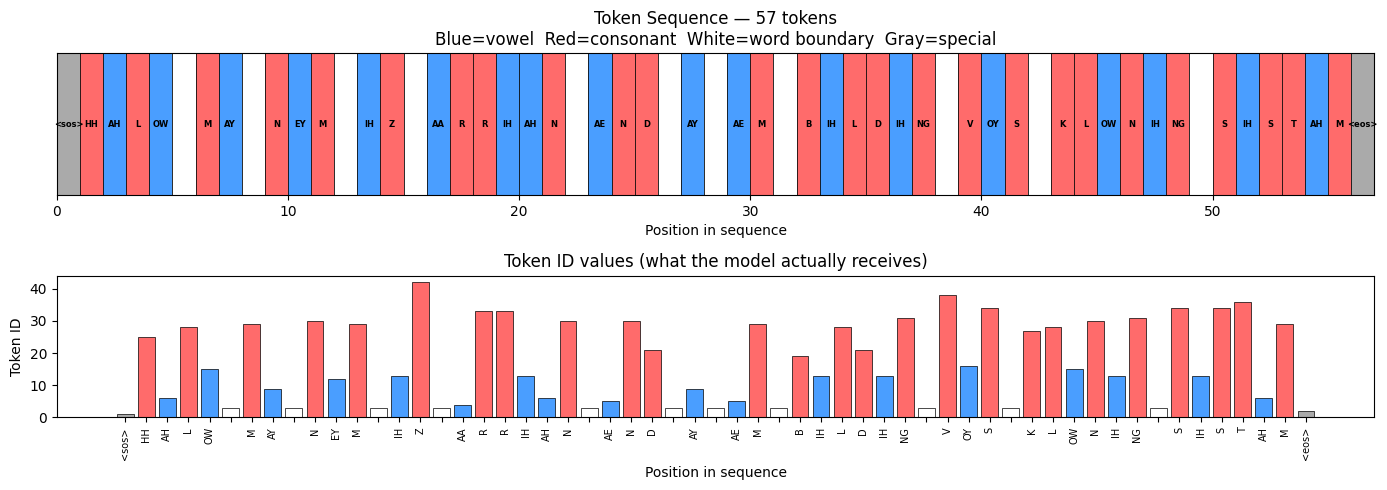


Sequence statistics:
  Total tokens : 57
  Vowels       : 18
  Consonants   : 26
  Word spaces  : 11  (= 12 words)


In [11]:
# This cell makes the abstract "token IDs" visual and concrete.
# We draw a color-coded bar where each color = a phoneme category.

fig, axes = plt.subplots(2, 1, figsize=(14, 5))

ids_list = tensor[0].tolist()
phoneme_labels = ids_to_phonemes(ids_list)

# ── Define colors by phoneme type ─────────────────────────────────────────
VOWELS     = {"AA","AE","AH","AO","AW","AY","EH","ER","EY","IH","IY","OW","OY","UH","UW"}
CONSONANTS = {"B","CH","D","DH","F","G","HH","JH","K","L","M","N","NG","P","R","S","SH","T","TH","V","W","Y","Z","ZH"}
SPECIAL    = {"<pad>","<sos>","<eos>"}

def get_color(ph):
    if ph in VOWELS:      return "#4a9eff"   # blue
    if ph in CONSONANTS:  return "#ff6b6b"   # red
    if ph == " ":         return "#ffffff"   # white (word boundary)
    return                       "#aaaaaa"   # gray (special tokens)

colors = [get_color(ph) for ph in phoneme_labels]

# ── Plot 1: color bar showing token sequence ───────────────────────────────
ax = axes[0]
for i, (ph, color) in enumerate(zip(phoneme_labels, colors)):
    rect = plt.Rectangle([i, 0], 1, 1, color=color, ec="black", lw=0.5)
    ax.add_patch(rect)
    ax.text(i + 0.5, 0.5, ph, ha="center", va="center",
            fontsize=6, fontweight="bold",
            color="black" if color != "#ffffff" else "gray")

ax.set_xlim(0, len(phoneme_labels))
ax.set_ylim(0, 1)
ax.set_title(f"Token Sequence — {len(phoneme_labels)} tokens\n"
             f"Blue=vowel  Red=consonant  White=word boundary  Gray=special")
ax.set_yticks([])
ax.set_xlabel("Position in sequence")

# ── Plot 2: token ID values ────────────────────────────────────────────────
ax = axes[1]
ax.bar(range(len(ids_list)), ids_list,
       color=[get_color(ph) for ph in phoneme_labels],
       edgecolor="black", linewidth=0.5)
ax.set_title("Token ID values (what the model actually receives)")
ax.set_xlabel("Position in sequence")
ax.set_ylabel("Token ID")
ax.set_xticks(range(len(ids_list)))
ax.set_xticklabels(phoneme_labels, rotation=90, fontsize=7)

plt.tight_layout()
plt.show()

print(f"\nSequence statistics:")
n_vowels     = sum(1 for ph in phoneme_labels if ph in VOWELS)
n_consonants = sum(1 for ph in phoneme_labels if ph in CONSONANTS)
n_spaces     = phoneme_labels.count(" ")
print(f"  Total tokens : {len(phoneme_labels)}")
print(f"  Vowels       : {n_vowels}")
print(f"  Consonants   : {n_consonants}")
print(f"  Word spaces  : {n_spaces}  (= {n_spaces+1} words)")

In [12]:
# A sanity check: phonemize → tokenize → detokenize should give back
# the same phoneme sequence. If not, our vocabulary has gaps.

print("Round-trip integrity check:")
print("-" * 60)

test_inputs = [
    "the cat sat on the mat",
    "she sells seashells by the seashore",
    "how much wood would a woodchuck chuck",
    "hello my name is aryan",
]

all_passed = True

for text in test_inputs:
    phonemes_original = text_to_phonemes(normalize_text(text))
    ids               = phonemes_to_ids(phonemes_original)
    phonemes_decoded  = ids_to_phonemes(ids)

    # Remove <sos> and <eos> from decoded for comparison
    phonemes_decoded_clean = [p for p in phonemes_decoded
                              if p not in ("<sos>", "<eos>")]

    passed = phonemes_original == phonemes_decoded_clean

    status = "✓" if passed else "✗"
    print(f"{status} '{text}'")
    if not passed:
        all_passed = False
        print(f"  Original: {phonemes_original}")
        print(f"  Decoded:  {phonemes_decoded_clean}")

print()
if all_passed:
    print("All round-trips passed — vocabulary is complete.")
else:
    print("Some phonemes are missing from vocabulary — check IPA→ARPAbet map.")

Round-trip integrity check:
------------------------------------------------------------
✓ 'the cat sat on the mat'
✓ 'she sells seashells by the seashore'
✓ 'how much wood would a woodchuck chuck'
✓ 'hello my name is aryan'

All round-trips passed — vocabulary is complete.


In [13]:
print("Week 2 Summary — Text Frontend")
print("=" * 60)
print()
print("Pipeline:")
print('  "Dr. Smith paid $50 in 2024."')
print("         ↓  normalize_text()")
print('  "doctor smith paid fifty dollars in twenty twenty four."')
print("         ↓  text_to_phonemes()")
print("  [D, AA, K, T, ER, ' ', S, M, IH, TH, ' ', P, EY, D, ...]")
print("         ↓  phonemes_to_ids()")
print("  [1, 12, 4, 19, 7, 14, 3, 25, 18, 8, 21, 3, 16, 9, 12, ..., 2]")
print("         ↓  torch.LongTensor().unsqueeze(0)")
print("  tensor shape: [1, sequence_length]")
print()
print("What each stage does:")
print("  normalize_text  : removes ambiguity (symbols, abbreviations, numbers)")
print("  text_to_phonemes: converts spelling → sound units (ARPAbet)")
print("  phonemes_to_ids : converts symbols → integers (model input)")
print("  pad_sequence    : makes variable-length sequences same length (batching)")
print("  make_padding_mask: tells attention what to ignore")
print()
print("What the model sees:")
print("  - A LongTensor of shape [batch_size, sequence_length]")
print("  - Each integer = one phoneme ID (0-42)")
print("  - 0 = padding (ignore), 1 = start, 2 = end, 3 = word boundary")
print()
print("Next: Week 3 — Speaker Encoder")
print("  The speaker encoder takes your voice audio and produces")
print("  a 256-dimensional vector that captures your vocal identity.")
print("  That vector gets injected into the acoustic model so it")
print("  knows whose voice to synthesize.")

Week 2 Summary — Text Frontend

Pipeline:
  "Dr. Smith paid $50 in 2024."
         ↓  normalize_text()
  "doctor smith paid fifty dollars in twenty twenty four."
         ↓  text_to_phonemes()
  [D, AA, K, T, ER, ' ', S, M, IH, TH, ' ', P, EY, D, ...]
         ↓  phonemes_to_ids()
  [1, 12, 4, 19, 7, 14, 3, 25, 18, 8, 21, 3, 16, 9, 12, ..., 2]
         ↓  torch.LongTensor().unsqueeze(0)
  tensor shape: [1, sequence_length]

What each stage does:
  normalize_text  : removes ambiguity (symbols, abbreviations, numbers)
  text_to_phonemes: converts spelling → sound units (ARPAbet)
  phonemes_to_ids : converts symbols → integers (model input)
  pad_sequence    : makes variable-length sequences same length (batching)
  make_padding_mask: tells attention what to ignore

What the model sees:
  - A LongTensor of shape [batch_size, sequence_length]
  - Each integer = one phoneme ID (0-42)
  - 0 = padding (ignore), 1 = start, 2 = end, 3 = word boundary

Next: Week 3 — Speaker Encoder
  The speake